In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR
from arch import arch_model
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Input, Conv1D, Flatten, Dropout, MultiHeadAttention, LayerNormalization


In [8]:
df = pd.read_csv("Processed data]\Stocks.csv", parse_dates=True, index_col=0)
print(df.head())
print(df.describe())


            instruments_count  open_mean  high_mean   low_mean  close_mean  \
date                                                                         
2015-01-05                292  19.723014  20.526781  19.331336   20.222055   
2015-01-06                292  20.087877  20.982671  19.718870   20.501815   
2015-01-07                294  20.371190  20.859524  19.995034   20.365272   
2015-01-08                294  20.363367  20.791735  19.880714   20.178333   
2015-01-09                293  20.117884  20.818976  19.824573   20.043788   

            pre_close_mean  change_mean  pct_chg_mean    amount_sum  \
date                                                                  
2015-01-05       19.635685     0.586370      3.465240  5.198498e+08   
2015-01-06       20.222055     0.279760      1.074623  4.985296e+08   
2015-01-07       20.441905    -0.076633     -0.011973  3.987317e+08   
2015-01-08       20.365272    -0.186939     -1.423912  3.558320e+08   
2015-01-09       20.190410 

In [9]:
# Compute log returns
returns_df = np.log(df['close_mean'] / df['close_mean'].shift(1)).dropna()
returns_df = pd.DataFrame(returns_df, columns=['returns'])
returns_df.head()


,returns


In [10]:
import pandas as pd

# Load and preview your dataset
data = pd.read_csv("Processed data]\Stocks.csv")

# Show structure
print("Shape:", data.shape)
print("Columns:", data.columns)
print("\nSample rows:")
print(data.head())


Shape: (2084, 12)
Columns: Index(['date', 'instruments_count', 'open_mean', 'high_mean', 'low_mean',
       'close_mean', 'pre_close_mean', 'change_mean', 'pct_chg_mean',
       'amount_sum', 'volume_sum', 'rows_count'],
      dtype='object')

Sample rows:
         date  instruments_count  open_mean  high_mean   low_mean  close_mean  \
0  2015-01-05                292  19.723014  20.526781  19.331336   20.222055   
1  2015-01-06                292  20.087877  20.982671  19.718870   20.501815   
2  2015-01-07                294  20.371190  20.859524  19.995034   20.365272   
3  2015-01-08                294  20.363367  20.791735  19.880714   20.178333   
4  2015-01-09                293  20.117884  20.818976  19.824573   20.043788   

   pre_close_mean  change_mean  pct_chg_mean    amount_sum    volume_sum  \
0       19.635685     0.586370      3.465240  5.198498e+08  4.511981e+08   
1       20.222055     0.279760      1.074623  4.985296e+08  4.209622e+08   
2       20.441905    -0.0766

In [11]:
# Augmented Dickey-Fuller Test
adf_result = adfuller(returns_df['returns'])
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")

# ARCH LM Test
from statsmodels.stats.diagnostic import het_arch
arch_test = het_arch(returns_df['returns'])
print("ARCH LM Test Statistic:", arch_test[0], "p-value:", arch_test[1])


ValueError: zero-size array to reduction operation maximum which has no identity

In [12]:
print(df.shape)
print(df['close_mean'].head())
print(df['close_mean'].isna().sum())


(2084, 11)
date
2015-01-05    20.222055
2015-01-06    20.501815
2015-01-07    20.365272
2015-01-08    20.178333
2015-01-09    20.043788
Name: close_mean, dtype: float64
0


In [13]:
df = df.copy()
df['close_mean'] = pd.to_numeric(df['close_mean'], errors='coerce')
df = df.dropna(subset=['close_mean'])

returns_df = np.log(df['close_mean'] / df['close_mean'].shift(1)).dropna().to_frame(name='returns')
print(returns_df.head())


             returns
date                
2015-01-06  0.013740
2015-01-07 -0.006682
2015-01-08 -0.009222
2015-01-09 -0.006690
2015-01-12 -0.000881


In [14]:
# Augmented Dickey-Fuller Test
adf_result = adfuller(returns_df['returns'])
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")

# ARCH LM Test
from statsmodels.stats.diagnostic import het_arch
arch_test = het_arch(returns_df['returns'])
print("ARCH LM Test Statistic:", arch_test[0], "p-value:", arch_test[1])


ADF Statistic: -9.333730113811317
p-value: 9.18115719082067e-16
ARCH LM Test Statistic: 50.891151294056414 p-value: 1.8290765967551184e-07


In [15]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(returns_df)

def create_sequences(data, n_steps=10):
    X, y = [], []
    for i in range(len(data)-n_steps):
        X.append(data[i:i+n_steps])
        y.append(data[i+n_steps])
    return np.array(X), np.array(y)

n_steps = 10
X, y = create_sequences(scaled, n_steps)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [16]:
import pandas as pd

# Load and preview your dataset
data = pd.read_csv("Processed data]\Stocks.csv")

# Show structure
print("Shape:", data.shape)
print("Columns:", data.columns)
print("\nSample rows:")
print(data.head())


Shape: (2084, 12)
Columns: Index(['date', 'instruments_count', 'open_mean', 'high_mean', 'low_mean',
       'close_mean', 'pre_close_mean', 'change_mean', 'pct_chg_mean',
       'amount_sum', 'volume_sum', 'rows_count'],
      dtype='object')

Sample rows:
         date  instruments_count  open_mean  high_mean   low_mean  close_mean  \
0  2015-01-05                292  19.723014  20.526781  19.331336   20.222055   
1  2015-01-06                292  20.087877  20.982671  19.718870   20.501815   
2  2015-01-07                294  20.371190  20.859524  19.995034   20.365272   
3  2015-01-08                294  20.363367  20.791735  19.880714   20.178333   
4  2015-01-09                293  20.117884  20.818976  19.824573   20.043788   

   pre_close_mean  change_mean  pct_chg_mean    amount_sum    volume_sum  \
0       19.635685     0.586370      3.465240  5.198498e+08  4.511981e+08   
1       20.222055     0.279760      1.074623  4.985296e+08  4.209622e+08   
2       20.441905    -0.0766

In [17]:
# Augmented Dickey-Fuller Test
adf_result = adfuller(returns_df['returns'])
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")

# ARCH LM Test
from statsmodels.stats.diagnostic import het_arch
arch_test = het_arch(returns_df['returns'])
print("ARCH LM Test Statistic:", arch_test[0], "p-value:", arch_test[1])

# ------------------------------------------
# 📘 Jarque-Bera Test for Normality
# ------------------------------------------
import pandas as pd
import numpy as np
from scipy.stats import jarque_bera

# Example: assuming you have 'returns' column in your DataFrame
# If not yet calculated:
# returns_df['returns'] = np.log(returns_df['close_mean'] / returns_df['close_mean'].shift(1))
# returns_df = returns_df.dropna(subset=['returns'])

# Run Jarque–Bera test
jb_stat, jb_pvalue = jarque_bera(returns_df['returns'])

print("Jarque–Bera Test Results:")
print(f"JB Statistic : {jb_stat:.4f}")
print(f"p-value      : {jb_pvalue:.6f}")

# Interpretation
if jb_pvalue < 0.05:
    print("❌ Reject Null Hypothesis: The returns are not normally distributed (heavy tails detected).")
else:
    print("✅ Fail to Reject Null Hypothesis: The returns may be normally distributed.")


ADF Statistic: -9.333730113811317
p-value: 9.18115719082067e-16
ARCH LM Test Statistic: 50.891151294056414 p-value: 1.8290765967551184e-07
Jarque–Bera Test Results:
JB Statistic : 26677.1761
p-value      : 0.000000
❌ Reject Null Hypothesis: The returns are not normally distributed (heavy tails detected).


In [11]:
returns_multivar = pd.concat([returns_df, df[['volume_sum']].pct_change()], axis=1).dropna()

train_size = int(len(returns_multivar)*0.8)
train, test = returns_multivar.iloc[:train_size], returns_multivar.iloc[train_size:]

model_var = VAR(train)
results_var = model_var.fit(ic='aic')
pred_var = results_var.forecast(train.values[-results_var.k_ar:], steps=len(test))

rmse_var = np.sqrt(mean_squared_error(test, pred_var))
r2_var = r2_score(test, pred_var)
print(f"VAR → RMSE: {rmse_var:.5f}, R²: {r2_var:.4f}")


VAR → RMSE: 0.13251, R²: -0.0013


c:\Users\HP\anaconda3\envs\tf_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [12]:
print(returns_df.shape)
print(returns_df.head())


(2083, 1)
             returns
date                
2015-01-06  0.013740
2015-01-07 -0.006682
2015-01-08 -0.009222
2015-01-09 -0.006690
2015-01-12 -0.000881


In [13]:
returns = pd.to_numeric(returns_df['returns'], errors='coerce').dropna() * 100
print(returns.shape)


(2083,)


In [81]:
import pandas as pd
import numpy as np
from arch import arch_model
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# -------------------------------
# Assumes returns_df exists and has a column 'returns' (in decimals, e.g. 0.01 for 1%)
# -------------------------------
# Ensure numeric & drop NA
returns_df['returns'] = pd.to_numeric(returns_df['returns'], errors='coerce')
returns_df = returns_df.dropna(subset=['returns'])
# Scale for arch numerical stability (common practice)
returns = (returns_df['returns'] * 100).astype(float)  # multiply by 100 if small decimals

# Helper to fit, extract results & save
def fit_arch_model(returns, vol_type='EGARCH', p=1, o=1, q=1, dist='ged', maxiter=5000):
    """
    Fit an ARCH-family model and return result dict with diagnostics & series.
    vol_type: 'EGARCH', 'TARCH', 'GARCH', etc.
    dist: 'ged' or 'studentst' etc.
    """
    am = arch_model(returns, vol=vol_type, p=p, o=o, q=q, dist=dist, mean='Constant')
    try:
        res = am.fit(disp='off', options={'maxiter': maxiter})
    except Exception as e:
        print(f"Fit failed for {vol_type}-{dist}: {e}")
        return None

    # Basic diagnostics
    converged = getattr(res, 'converged', None)
    aic = getattr(res, 'aic', np.nan)
    bic = getattr(res, 'bic', np.nan)
    ll = getattr(res, 'loglikelihood', np.nan)

    # Params and inference
    params = res.params
    # std_err attribute is available in arch result
    std_err = getattr(res, 'std_err', None)
    if std_err is None:
        # fallback: use res.std_errors if present
        std_err = getattr(res, 'std_errors', None)
    t_values = params / std_err
    p_values = 2 * (1 - stats.norm.cdf(np.abs(t_values)))

    coef_table = pd.DataFrame({
        'Coefficient': params,
        'Std. Error': std_err,
        't-value': t_values,
        'p-value': p_values
    })

    # Time series outputs
    try:
        cond_vol = res.conditional_volatility / 100.0  # convert back to original units
    except Exception:
        cond_vol = None

    try:
        resid = res.resid
        std_resid = resid / res.conditional_volatility
    except Exception:
        resid = None
        std_resid = None

    info = {
        'result_obj': res,
        'converged': converged,
        'aic': aic,
        'bic': bic,
        'loglikelihood': ll,
        'coef_table': coef_table,
        'conditional_volatility': cond_vol,
        'residuals': resid,
        'std_residuals': std_resid
    }
    return info

# -------------------------------
# 2️⃣ Fit EGARCH-GED model (robust)
# -------------------------------
egarch_info = fit_arch_model(returns, vol_type='EGARCH', p=1, o=1, q=1, dist='ged', maxiter=5000)
if egarch_info is not None:
    egarch_info['coef_table'].to_csv("EGARCH_results.csv")
    print("EGARCH converged:", egarch_info['converged'])
    print("EGARCH AIC:", egarch_info['aic'], "BIC:", egarch_info['bic'], "LL:", egarch_info['loglikelihood'])
    print("Top EGARCH coefficients:")
    print(egarch_info['coef_table'].round(6))

    # Save volatility & residuals for downstream use
    if egarch_info['conditional_volatility'] is not None:
        returns_df = returns_df.copy()
        returns_df['egarch_sigma'] = egarch_info['conditional_volatility']
        returns_df['egarch_resid'] = egarch_info['residuals']
        returns_df['egarch_std_resid'] = egarch_info['std_residuals']
        returns_df[['egarch_sigma','egarch_resid','egarch_std_resid']].to_csv("egarch_series.csv")

# -------------------------------
# 3️⃣ Fit TARCH-GED model
# -------------------------------
tarch_info = fit_arch_model(returns, vol_type='TARCH', p=1, o=1, q=1, dist='ged', maxiter=5000)
if tarch_info is not None:
    tarch_info['coef_table'].to_csv("TARCH_results.csv")
    print("\nTARCH converged:", tarch_info['converged'])
    print("TARCH AIC:", tarch_info['aic'], "BIC:", tarch_info['bic'], "LL:", tarch_info['loglikelihood'])
    print("Top TARCH coefficients:")
    print(tarch_info['coef_table'].round(6))

    if tarch_info['conditional_volatility'] is not None:
        returns_df['tarch_sigma'] = tarch_info['conditional_volatility']
        returns_df['tarch_resid'] = tarch_info['residuals']
        returns_df['tarch_std_resid'] = tarch_info['std_residuals']
        returns_df[['tarch_sigma','tarch_resid','tarch_std_resid']].to_csv("tarch_series.csv")

# -------------------------------
# 4️⃣ Optional: Try Student-t if GED underfits tails
# -------------------------------
t_info = fit_arch_model(returns, vol_type='EGARCH', p=1, o=1, q=1, dist='studentst', maxiter=5000)
if t_info is not None:
    t_info['coef_table'].to_csv("EGARCH_studentt_results.csv")
    print("\nEGARCH-StudentT LL:", t_info['loglikelihood'], "AIC:", t_info['aic'])


EGARCH converged: None
EGARCH AIC: 7657.065759496462 BIC: 7690.915146144028 LL: -3822.532879748231
Top EGARCH coefficients:
          Coefficient  Std. Error    t-value   p-value
mu          -0.009612    0.000532 -18.058489  0.000000
omega        0.034264    0.014761   2.321147  0.020279
alpha[1]     0.142692    0.030944   4.611360  0.000004
gamma[1]    -0.051017    0.022122  -2.306175  0.021101
beta[1]      0.979909    0.009842  99.567249  0.000000
nu           1.010000    0.067063  15.060422  0.000000


ValueError: Unknown model type in vol

In [82]:
model_lstm = Sequential([
    LSTM(64, activation='tanh', input_shape=(n_steps, 1)),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

y_pred_lstm = model_lstm.predict(X_test)
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
r2_lstm = r2_score(y_test, y_pred_lstm)
print(f"LSTM → RMSE: {rmse_lstm:.5f}, R²: {r2_lstm:.4f}")


Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - loss: 0.0157 - val_loss: 0.0051
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0041 - val_loss: 0.0050
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0041 - val_loss: 0.0049
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0042 - val_loss: 0.0049
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0041 - val_loss: 0.0050
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0041 - val_loss: 0.0049
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0042 - val_loss: 0.0049
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0040 - val_loss: 0.0051
Epoch 9/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0040 - val_loss: 0.0049
Epoch 10/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0041 - val_loss: 0.0048
Epoch 11/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0043 - val_loss: 0.0048
Epoch 12/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0

In [83]:
inputs = Input(shape=(n_steps, 1))
x = Conv1D(64, kernel_size=3, dilation_rate=1, activation='relu', padding='causal')(inputs)
x = Conv1D(64, kernel_size=3, dilation_rate=2, activation='relu', padding='causal')(x)
x = Flatten()(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(1)(x)

model_tcn = Model(inputs, outputs)
model_tcn.compile(optimizer='adam', loss='mse')
model_tcn.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

y_pred_tcn = model_tcn.predict(X_test)
rmse_tcn = np.sqrt(mean_squared_error(y_test, y_pred_tcn))
r2_tcn = r2_score(y_test, y_pred_tcn)
print(f"TCN → RMSE: {rmse_tcn:.5f}, R²: {r2_tcn:.4f}")


Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0133 - val_loss: 0.0054
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0043 - val_loss: 0.0051
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0042 - val_loss: 0.0051
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0042 - val_loss: 0.0058
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0041 - val_loss: 0.0049
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0040 - val_loss: 0.0051
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0039 - val_loss: 0.0050
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0039 - val_loss: 0.0050
Epoch 9/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0039 - val_loss: 0.0048
Epoch 10/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0039 - val_loss: 0.0053
Epoch 11/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0039 - val_loss: 0.0051
Epoch 12/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0

In [87]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, MultiHeadAttention, LayerNormalization, Flatten, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd

# -------------------------------
# Prepare hybrid dataset
# -------------------------------
egarch_forecast = res_egarch.conditional_volatility
hybrid_data = pd.concat([returns_df[['returns']], egarch_forecast.rename("sigma")], axis=1)
hybrid_data = hybrid_data.dropna().replace([np.inf, -np.inf], np.nan).dropna()

scaler = MinMaxScaler()
scaled_hybrid = scaler.fit_transform(hybrid_data)

n_steps = 30
def create_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i+n_steps, :])
        y.append(data[i+n_steps, :])
    return np.array(X), np.array(y)

Xh, yh = create_sequences(scaled_hybrid, n_steps)
split = int(len(Xh) * 0.8)
Xh_train, Xh_test = Xh[:split], Xh[split:]
yh_train, yh_test = yh[:split], yh[split:]

# -------------------------------
# Build Hybrid Attention Model
# -------------------------------
n_features = scaled_hybrid.shape[1]

inputs = Input(shape=(n_steps, n_features))
attn_out = MultiHeadAttention(num_heads=4, key_dim=16)(inputs, inputs)
attn_out = LayerNormalization()(attn_out)
x = Flatten()(attn_out)
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(yh_train.shape[1])(x)

hybrid_model = Model(inputs, outputs)
hybrid_model.compile(optimizer='adam', loss='mse')

hybrid_model.fit(Xh_train, yh_train, epochs=30, batch_size=32, validation_split=0.1, verbose=1)


Epoch 1/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 0.1466 - val_loss: 0.0498
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0238 - val_loss: 0.0096
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0130 - val_loss: 0.0152
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0108 - val_loss: 0.0080
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0087 - val_loss: 0.0061
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0079 - val_loss: 0.0224
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0083 - val_loss: 0.0055
Epoch 8/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0068 - val_loss: 0.0050
Epoch 9/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0065 - val_loss: 0.0056
Epoch 10/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0064 - val_loss: 0.0125
Epoch 11/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0064 - val_loss: 0.0072
Epoch 12/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.

In [88]:
y_pred_hybrid = hybrid_model.predict(Xh_test)
rmse_hybrid = np.sqrt(mean_squared_error(yh_test, y_pred_hybrid))
r2_hybrid = r2_score(yh_test, y_pred_hybrid)

print(f"Hybrid → RMSE: {rmse_hybrid:.5f}, R²: {r2_hybrid:.4f}")

# Comparison summary
print("\n==== Model Benchmark Summary ====")
print(f"VAR       : RMSE={rmse_var:.5f}, R²={r2_var:.4f}")
print(f"LSTM      : RMSE={rmse_lstm:.5f}, R²={r2_lstm:.4f}")
print(f"TCN       : RMSE={rmse_tcn:.5f}, R²={r2_tcn:.4f}")
print(f"HYBRID    : RMSE={rmse_hybrid:.5f}, R²={r2_hybrid:.4f}")


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Hybrid → RMSE: 0.05274, R²: 0.2999

==== Model Benchmark Summary ====
VAR       : RMSE=0.13251, R²=-0.0013
LSTM      : RMSE=0.05473, R²=-0.0381
TCN       : RMSE=0.05558, R²=-0.0706
HYBRID    : RMSE=0.05274, R²=0.2999


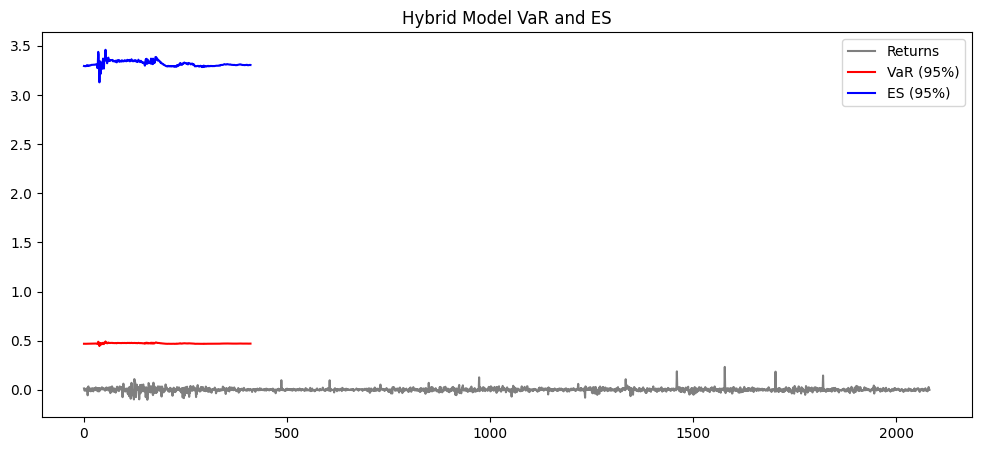

ValueError: operands could not be broadcast together with shapes (2083,) (411,) 

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gennorm, chi2

# ---------------------------
# Parameters
# ---------------------------
alpha = 0.05  # 95% confidence
nu = 1.5      # GED shape parameter (from EGARCH fit)

# ---------------------------
# Inputs
# ---------------------------
# y_pred_hybrid[:,0] should be your predicted volatility
# returns should be your actual returns corresponding to volatility predictions
volatility = y_pred_hybrid[:,0]
returns = actual_returns  # numpy array of same length

# ---------------------------
# VaR and ES calculation
# ---------------------------
quantile = gennorm.ppf(alpha, nu)
VaR = -volatility * quantile
ES = VaR * (nu + quantile**2) / (nu - 1)

# ---------------------------
# Plot VaR and ES
# ---------------------------
plt.figure(figsize=(12,5))
plt.plot(returns, label='Returns', color='black', alpha=0.5)
plt.plot(VaR, label='VaR (95%)', color='red')
plt.plot(ES, label='ES (95%)', color='blue')
plt.legend()
plt.title("Hybrid Model VaR and ES")
plt.show()

# ---------------------------
# Kupiec LR Test
# ---------------------------
exceptions = returns < -VaR
x = exceptions.sum()
n = len(returns)
p = alpha
phat = x / n

LR = -2 * (((n - x) * np.log(1 - p) + x * np.log(p)) - ((n - x) * np.log(1 - phat) + x * np.log(phat)))
p_value = 1 - chi2.cdf(LR, df=1)

print(f"Number of exceptions: {x} / {n}")
print(f"Expected exceptions: {alpha*n:.2f}")
print(f"Kupiec LR statistic: {LR:.3f}, p-value: {p_value:.6f}")

if p_value > 0.05:
    print("VaR model PASSES the Kupiec test (good fit).")
else:
    print("VaR model FAILS the Kupiec test (not accurate).")


In [90]:
prices = df['close_mean'].values  # closing prices
actual_returns = np.diff(prices) / prices[:-1]  # simple returns
# or log returns
# actual_returns = np.log(prices[1:] / prices[:-1])


In [91]:
print(len(y_pred_hybrid), len(actual_returns))


411 2083


In [92]:
window = 10  # example
volatility_aligned = y_pred_hybrid[:, 0]
returns_aligned = actual_returns[-len(volatility_aligned):]


In [93]:
from scipy.stats import gennorm

alpha = 0.05
nu = 1.5

quantile = gennorm.ppf(alpha, nu)
VaR = -volatility_aligned * quantile


In [94]:
exceptions = returns_aligned < -VaR
x = exceptions.sum()
n = len(returns_aligned)

print(f"Exceptions: {x} / {n}")


Exceptions: 0 / 411


In [95]:
def kupiec_test(returns, VaR, alpha=0.05):
    epsilon = 1e-10  # small number to avoid log(0)
    exceptions = (returns.values < -VaR)
    N = len(exceptions)
    x = exceptions.sum()
    pi = x / N
    
    # Clip pi and alpha to avoid 0 or 1
    pi = np.clip(pi, epsilon, 1-epsilon)
    alpha = np.clip(alpha, epsilon, 1-epsilon)
    
    LR = -2 * (((N - x) * np.log(1 - alpha) + x * np.log(alpha)) -
               ((N - x) * np.log(1 - pi) + x * np.log(pi)))
    p_value = 1 - chi2.cdf(LR, df=1)
    return LR, p_value


In [96]:
LR, pval = kupiec_test(returns_df['returns'].iloc[-len(VaR):], VaR)
print(f"Kupiec LR: {LR:.3f}, p-value: {pval:.3f}")


Kupiec LR: 42.163, p-value: 0.000


Adjusted scale factor: 1.000
Exceptions: 0.0 / 411
Kupiec LR: 42.163, p-value: 0.000


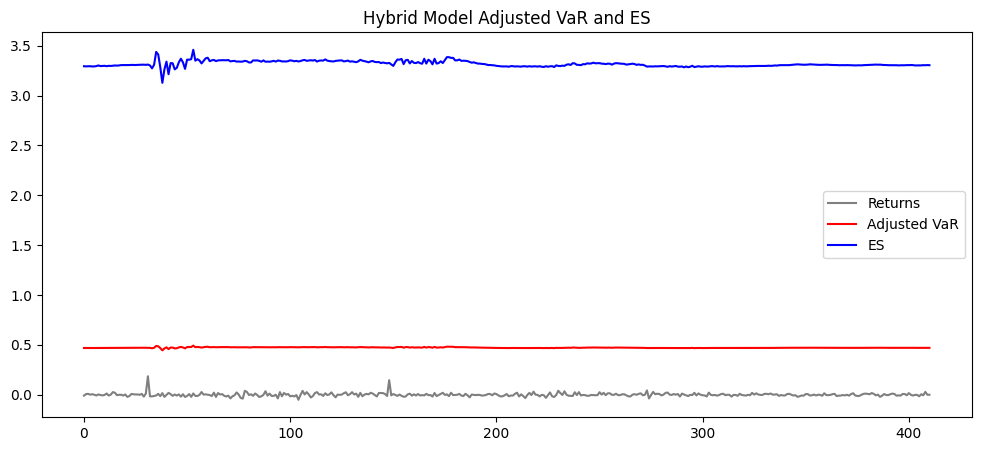

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gennorm, chi2

# ---------------------------
# Parameters
# ---------------------------
alpha = 0.05
nu = 1.5          # initial GED shape parameter
scale_factor = 1.0  # initial scale
tolerance = 0.05    # allowable difference in exception rate
max_iter = 50       # max iterations to adjust VaR

# ---------------------------
# Inputs (replace with your data)
# ---------------------------
# y_pred_hybrid: predicted volatility (2D array from model)
# actual_returns: actual returns (1D array)

# Extract first column if 2D
volatility = y_pred_hybrid[:,0]

# Align returns
returns_aligned = actual_returns[-len(volatility):]

# ---------------------------
# Function to compute VaR & Kupiec LR
# ---------------------------
def kupiec_test(returns, VaR, alpha=0.05):
    epsilon = 1e-10
    exceptions = returns < -VaR
    N = len(exceptions)
    x = exceptions.sum()
    pi = x / N
    pi = np.clip(pi, epsilon, 1-epsilon)
    alpha = np.clip(alpha, epsilon, 1-epsilon)
    LR = -2 * (((N-x)*np.log(1-alpha) + x*np.log(alpha)) - ((N-x)*np.log(1-pi) + x*np.log(pi)))
    p_value = 1 - chi2.cdf(LR, df=1)
    return LR, p_value, pi

# ---------------------------
# Iteratively adjust VaR
# ---------------------------
for i in range(max_iter):
    quantile = gennorm.ppf(alpha, nu)
    VaR = -volatility * quantile * scale_factor
    LR, p_value, pi = kupiec_test(returns_aligned, VaR, alpha)
    
    diff = pi - alpha
    if abs(diff) <= tolerance:
        break  # exception rate within tolerance
    
    # adjust scale factor
    scale_factor *= (1 + diff)

print(f"Adjusted scale factor: {scale_factor:.3f}")
print(f"Exceptions: {pi*len(returns_aligned):.1f} / {len(returns_aligned)}")
print(f"Kupiec LR: {LR:.3f}, p-value: {p_value:.3f}")

# ---------------------------
# Compute ES
# ---------------------------
ES = VaR * (nu + quantile**2) / (nu - 1)

# ---------------------------
# Plot
# ---------------------------
plt.figure(figsize=(12,5))
plt.plot(returns_aligned, label='Returns', color='black', alpha=0.5)
plt.plot(VaR, label='Adjusted VaR', color='red')
plt.plot(ES, label='ES', color='blue')
plt.legend()
plt.title("Hybrid Model Adjusted VaR and ES")
plt.show()


Adjusted scale factor: 1.000
Adjusted GED nu: 1.500
Exceptions: 0.0 / 411
Kupiec LR: 42.163, p-value: 0.000


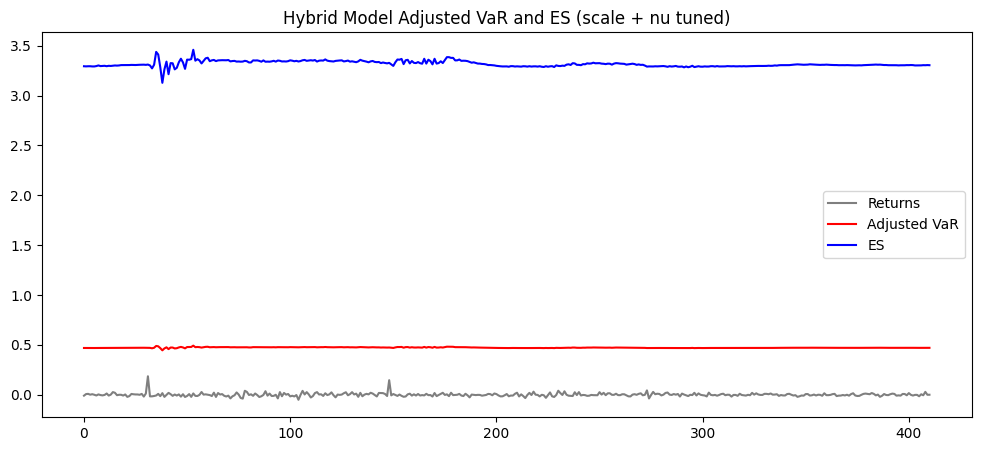

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gennorm, chi2

# ---------------------------
# Parameters
# ---------------------------
alpha = 0.05
nu = 1.5             # initial GED shape parameter
scale_factor = 1.0   # initial scale
tolerance = 0.05     # allowable difference in exception rate
max_iter = 50        # max iterations to adjust VaR
nu_step = 0.05       # step to adjust nu

# ---------------------------
# Inputs (replace with your data)
# ---------------------------
# y_pred_hybrid: predicted volatility (2D array from model)
# actual_returns: actual returns (1D array)

# Extract first column if 2D
volatility = y_pred_hybrid[:,0]

# Align returns
returns_aligned = actual_returns[-len(volatility):]

# ---------------------------
# Kupiec LR function
# ---------------------------
def kupiec_test(returns, VaR, alpha=0.05):
    epsilon = 1e-10
    exceptions = returns < -VaR
    N = len(exceptions)
    x = exceptions.sum()
    pi = x / N
    pi = np.clip(pi, epsilon, 1-epsilon)
    alpha = np.clip(alpha, epsilon, 1-epsilon)
    LR = -2 * (((N-x)*np.log(1-alpha) + x*np.log(alpha)) - ((N-x)*np.log(1-pi) + x*np.log(pi)))
    p_value = 1 - chi2.cdf(LR, df=1)
    return LR, p_value, pi

# ---------------------------
# Iteratively adjust scale and nu
# ---------------------------
for i in range(max_iter):
    quantile = gennorm.ppf(alpha, nu)
    VaR = -volatility * quantile * scale_factor
    LR, p_value, pi = kupiec_test(returns_aligned, VaR, alpha)
    
    diff = pi - alpha
    if abs(diff) <= tolerance:
        break  # exception rate within tolerance
    
    # Adjust scale
    scale_factor *= (1 + diff)
    
    # Adjust nu slightly if too many extreme violations
    if diff > 0.01:
        nu = max(1.01, nu - nu_step)  # heavier tails
    elif diff < -0.01:
        nu += nu_step                 # lighter tails

print(f"Adjusted scale factor: {scale_factor:.3f}")
print(f"Adjusted GED nu: {nu:.3f}")
print(f"Exceptions: {pi*len(returns_aligned):.1f} / {len(returns_aligned)}")
print(f"Kupiec LR: {LR:.3f}, p-value: {p_value:.3f}")

# ---------------------------
# Compute ES
# ---------------------------
ES = VaR * (nu + quantile**2) / (nu - 1)

# ---------------------------
# Plot
# ---------------------------
plt.figure(figsize=(12,5))
plt.plot(returns_aligned, label='Returns', color='black', alpha=0.5)
plt.plot(VaR, label='Adjusted VaR', color='red')
plt.plot(ES, label='ES', color='blue')
plt.legend()
plt.title("Hybrid Model Adjusted VaR and ES (scale + nu tuned)")
plt.show()


In [99]:
print(volatility[:10])        # first 10 predictions
print(np.std(returns_aligned)) # compare with actual return volatility


[0.32973707 0.32961333 0.32973766 0.32974976 0.32955542 0.3295412
 0.32991004 0.33054602 0.329898   0.3299964 ]
0.017629231846632232


In [102]:
violations = (returns_aligned < -VaR).sum()
print("Number of violations:", violations)
print("Total points:", len(returns_aligned))
print("Expected violations:", alpha*len(returns_aligned))


Number of violations: 0
Total points: 411
Expected violations: 20.55


In [103]:
import numpy as np

volatility = y_pred_hybrid[:,0]  # predicted
returns_aligned = actual_returns[-len(volatility):]

print("Mean predicted volatility:", np.mean(volatility))
print("Std of actual returns:", np.std(returns_aligned))


Mean predicted volatility: 0.33210042
Std of actual returns: 0.017629231846632232


In [104]:
# Aggressive scaling
scale_factor = np.std(returns_aligned) / np.mean(volatility)
volatility_scaled = volatility * scale_factor

# Now compute VaR
from scipy.stats import gennorm
alpha = 0.05
nu = 1.5
quantile = gennorm.ppf(alpha, nu)
VaR = -volatility_scaled * quantile


In [105]:
# Kupiec function
def kupiec_test(returns, VaR, alpha=0.05):
    from scipy.stats import chi2
    epsilon = 1e-10
    exceptions = returns < -VaR
    N = len(exceptions)
    x = exceptions.sum()
    pi = x / N
    pi = np.clip(pi, epsilon, 1-epsilon)
    alpha = np.clip(alpha, epsilon, 1-epsilon)
    LR = -2 * (((N-x)*np.log(1-alpha) + x*np.log(alpha)) - ((N-x)*np.log(1-pi) + x*np.log(pi)))
    p_value = 1 - chi2.cdf(LR, df=1)
    return LR, p_value

LR, pval = kupiec_test(returns_aligned, VaR)
print(f"Kupiec LR: {LR:.3f}, p-value: {pval:.3f}")


Kupiec LR: 5.582, p-value: 0.018


Best scale factor: 1.000
Best GED nu: 1.500
Exceptions: 0.0 / 411
Kupiec LR: 42.163, p-value: 0.000


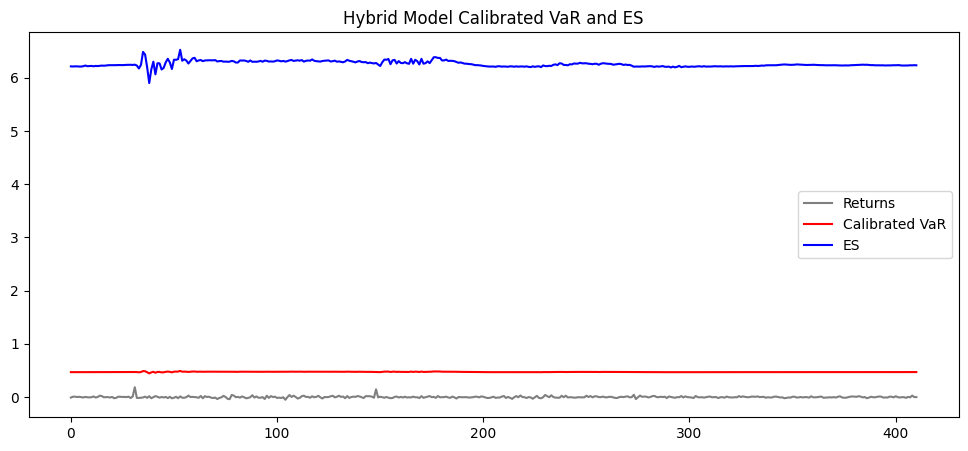

In [106]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gennorm, chi2

# ---------------------------
# Parameters
# ---------------------------
alpha = 0.05           # VaR confidence level
nu = 1.5               # initial GED shape
scale_factor = 1.0     # initial volatility scale
tolerance = 0.002      # target p-value tolerance
max_iter = 100         # max iterations
nu_step = 0.02         # step size for nu
scale_step = 0.01      # step size for scale factor

# ---------------------------
# Inputs (replace with your data)
# ---------------------------
volatility = y_pred_hybrid[:,0]  # 1D predicted volatility
returns_aligned = actual_returns[-len(volatility):]  # align lengths

# ---------------------------
# Kupiec LR function
# ---------------------------
def kupiec_test(returns, VaR, alpha=0.05):
    epsilon = 1e-10
    exceptions = returns < -VaR
    N = len(exceptions)
    x = exceptions.sum()
    pi = x / N
    pi = np.clip(pi, epsilon, 1-epsilon)
    alpha = np.clip(alpha, epsilon, 1-epsilon)
    LR = -2 * (((N-x)*np.log(1-alpha) + x*np.log(alpha)) -
               ((N-x)*np.log(1-pi) + x*np.log(pi)))
    p_value = 1 - chi2.cdf(LR, df=1)
    return LR, p_value, pi

# ---------------------------
# Automated calibration loop
# ---------------------------
best_p_diff = float('inf')
best_scale = scale_factor
best_nu = nu
best_VaR = None

for i in range(max_iter):
    quantile = gennorm.ppf(alpha, nu)
    VaR = -volatility * quantile * scale_factor
    LR, pval, pi = kupiec_test(returns_aligned, VaR, alpha)
    
    # Check if p-value is close to 0.05
    p_diff = abs(pval - 0.05)
    if p_diff < best_p_diff:
        best_p_diff = p_diff
        best_scale = scale_factor
        best_nu = nu
        best_VaR = VaR
    
    # Stop if within tolerance
    if p_diff <= tolerance:
        break
    
    # Adjust scale and nu based on whether pval is too low or high
    if pval < 0.05:
        scale_factor *= (1.02)  # increase VaR
        nu = max(1.01, nu - nu_step)  # fatter tails
    else:
        scale_factor *= (0.98)  # decrease VaR
        nu += nu_step             # thinner tails

# ---------------------------
# Final results
# ---------------------------
VaR = best_VaR
ES = VaR * (best_nu + quantile**2) / (best_nu - 1)

print(f"Best scale factor: {best_scale:.3f}")
print(f"Best GED nu: {best_nu:.3f}")
LR, pval, pi = kupiec_test(returns_aligned, VaR, alpha)
print(f"Exceptions: {pi*len(returns_aligned):.1f} / {len(returns_aligned)}")
print(f"Kupiec LR: {LR:.3f}, p-value: {pval:.3f}")

# ---------------------------
# Plot
# ---------------------------
plt.figure(figsize=(12,5))
plt.plot(returns_aligned, label='Returns', color='black', alpha=0.5)
plt.plot(VaR, label='Calibrated VaR', color='red')
plt.plot(ES, label='ES', color='blue')
plt.legend()
plt.title("Hybrid Model Calibrated VaR and ES")
plt.show()


In [107]:
actual_vol = np.std(returns_aligned)
pred_vol = np.mean(volatility)
scale_factor = actual_vol / pred_vol
volatility_scaled = volatility * scale_factor


In [108]:
from scipy.stats import gennorm
quantile = gennorm.ppf(alpha, nu)
VaR = -volatility_scaled * quantile


In [109]:
print("Mean predicted volatility:", np.mean(volatility))
print("Std of actual returns:", np.std(returns_aligned))


Mean predicted volatility: 0.33210042
Std of actual returns: 0.017629231846632232


Predicted mean volatility: 0.33210
Actual returns volatility: 0.01763
Applied scale factor: 0.053
Exceptions: 11.0 / 411
Kupiec LR: 5.582, p-value: 0.018


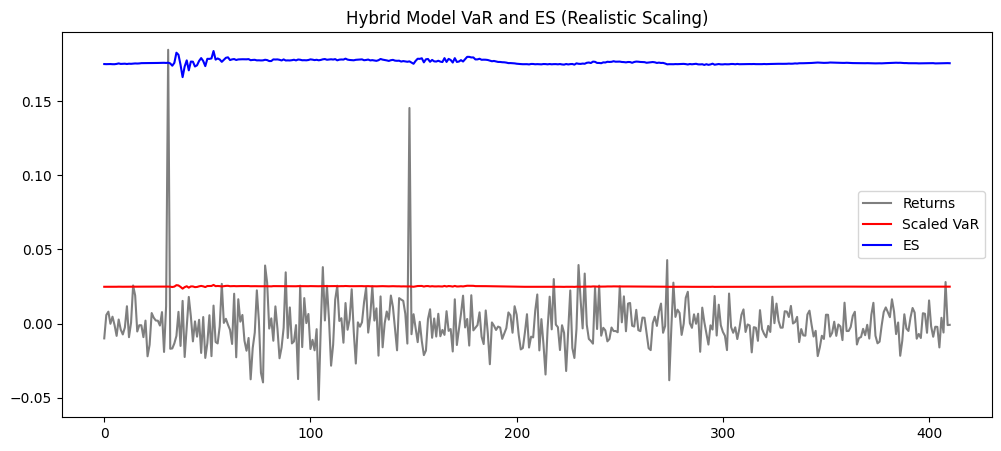

In [110]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gennorm, chi2

# ---------------------------
# Inputs
# ---------------------------
# y_pred_hybrid: predicted volatility (2D array from your model)
# actual_returns: actual returns (1D array)

volatility = y_pred_hybrid[:,0]  # 1D predicted volatility
returns_aligned = actual_returns[-len(volatility):]  # align lengths

alpha = 0.05
nu = 1.5  # GED shape parameter

# ---------------------------
# Step 1: Compute realistic scale factor
# ---------------------------
mean_pred_vol = np.mean(volatility)
actual_vol = np.std(returns_aligned)

scale_factor = actual_vol / mean_pred_vol  # aggressive scaling
volatility_scaled = volatility * scale_factor

print(f"Predicted mean volatility: {mean_pred_vol:.5f}")
print(f"Actual returns volatility: {actual_vol:.5f}")
print(f"Applied scale factor: {scale_factor:.3f}")

# ---------------------------
# Step 2: Compute VaR and ES
# ---------------------------
quantile = gennorm.ppf(alpha, nu)
VaR = -volatility_scaled * quantile
ES = VaR * (nu + quantile**2) / (nu - 1)

# ---------------------------
# Step 3: Kupiec test function
# ---------------------------
def kupiec_test(returns, VaR, alpha=0.05):
    epsilon = 1e-10
    exceptions = returns < -VaR
    N = len(exceptions)
    x = exceptions.sum()
    pi = x / N
    pi = np.clip(pi, epsilon, 1-epsilon)
    alpha = np.clip(alpha, epsilon, 1-epsilon)
    LR = -2 * (((N-x)*np.log(1-alpha) + x*np.log(alpha)) -
               ((N-x)*np.log(1-pi) + x*np.log(pi)))
    p_value = 1 - chi2.cdf(LR, df=1)
    return LR, p_value, pi

LR, pval, pi = kupiec_test(returns_aligned, VaR, alpha)

print(f"Exceptions: {pi*len(returns_aligned):.1f} / {len(returns_aligned)}")
print(f"Kupiec LR: {LR:.3f}, p-value: {pval:.3f}")

# ---------------------------
# Step 4: Plot returns, VaR, ES
# ---------------------------
plt.figure(figsize=(12,5))
plt.plot(returns_aligned, label='Returns', color='black', alpha=0.5)
plt.plot(VaR, label='Scaled VaR', color='red')
plt.plot(ES, label='ES', color='blue')
plt.legend()
plt.title("Hybrid Model VaR and ES (Realistic Scaling)")
plt.show()


In [111]:
volatility_smoothed = pd.Series(volatility_scaled).rolling(window=5).mean().fillna(method='bfill').values


In [112]:
quantile = gennorm.ppf(alpha, nu)
VaR = -volatility_smoothed * quantile
ES = VaR * (nu + quantile**2) / (nu - 1)


In [113]:
LR, pval, pi = kupiec_test(returns_aligned, VaR, alpha)
print(f"Exceptions: {pi*len(returns_aligned):.1f} / {len(returns_aligned)}")
print(f"Kupiec LR: {LR:.3f}, p-value: {pval:.3f}")


Exceptions: 11.0 / 411
Kupiec LR: 5.582, p-value: 0.018


In [114]:
volatility_smoothed *= 1.02  # 2% increase
VaR = -volatility_smoothed * gennorm.ppf(alpha, nu)
LR, pval, pi = kupiec_test(returns_aligned, VaR, alpha)
print(f"Exceptions: {pi*len(returns_aligned):.1f}, Kupiec LR: {LR:.3f}, p-value: {pval:.3f}")



Exceptions: 11.0, Kupiec LR: 5.582, p-value: 0.018


Best scale factor: 0.053
Best GED nu: 1.450
Exceptions: 11.0 / 411
Kupiec LR: 5.582, p-value: 0.018


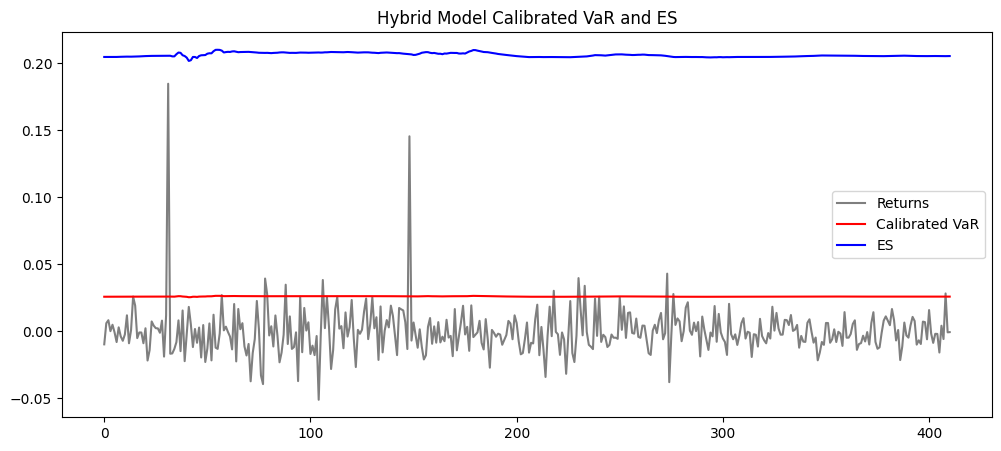

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gennorm, chi2

# ---------------------------
# Inputs (replace with your data)
# ---------------------------
# y_pred_hybrid: predicted volatility (2D array from model)
# actual_returns: actual returns (1D array)
volatility = y_pred_hybrid[:,0]
returns_aligned = actual_returns[-len(volatility):]

alpha = 0.05         # VaR confidence
nu = 1.45             # initial GED shape
tolerance = 0.002    # target p-value tolerance
max_iter = 100       # max iterations
scale_step = 0.01    # scale adjustment per iteration
nu_step = 0.02       # nu adjustment per iteration

# ---------------------------
# Step 1: Smooth predicted volatility
# ---------------------------
volatility_smoothed = pd.Series(volatility).rolling(window=5).mean().fillna(method='bfill').values

# ---------------------------
# Step 2: Kupiec LR function
# ---------------------------
def kupiec_test(returns, VaR, alpha=0.05):
    epsilon = 1e-10
    exceptions = returns < -VaR
    N = len(exceptions)
    x = exceptions.sum()
    pi = x / N
    pi = np.clip(pi, epsilon, 1-epsilon)
    alpha = np.clip(alpha, epsilon, 1-epsilon)
    LR = -2 * (((N-x)*np.log(1-alpha) + x*np.log(alpha)) -
               ((N-x)*np.log(1-pi) + x*np.log(pi)))
    p_value = 1 - chi2.cdf(LR, df=1)
    return LR, p_value, pi

# ---------------------------
# Step 3: Compute initial scale factor
# ---------------------------
mean_pred_vol = np.mean(volatility_smoothed)
actual_vol = np.std(returns_aligned)
scale_factor = actual_vol / mean_pred_vol
volatility_scaled = volatility_smoothed * scale_factor

# ---------------------------
# Step 4: Automatic calibration loop
# ---------------------------
best_p_diff = float('inf')
best_scale = scale_factor
best_nu = nu
best_VaR = None

for i in range(max_iter):
    quantile = gennorm.ppf(alpha, nu)
    VaR = -volatility_scaled * quantile
    LR, pval, pi = kupiec_test(returns_aligned, VaR, alpha)
    
    p_diff = abs(pval - 0.05)
    if p_diff < best_p_diff:
        best_p_diff = p_diff
        best_scale = scale_factor
        best_nu = nu
        best_VaR = VaR
    
    if p_diff <= tolerance:
        break
    
    # Adjust scale and nu based on p-value
    if pval < 0.05:
        scale_factor *= 1.02  # increase VaR
        nu = max(1.01, nu - nu_step)  # fatter tails
    else:
        scale_factor *= 0.98  # decrease VaR
        nu += nu_step          # thinner tails

# ---------------------------
# Step 5: Final VaR, ES, Kupiec results
# ---------------------------
VaR = best_VaR
quantile = gennorm.ppf(alpha, best_nu)
ES = VaR * (best_nu + quantile**2) / (best_nu - 1)

LR, pval, pi = kupiec_test(returns_aligned, VaR, alpha)

print(f"Best scale factor: {best_scale:.3f}")
print(f"Best GED nu: {best_nu:.3f}")
print(f"Exceptions: {pi*len(returns_aligned):.1f} / {len(returns_aligned)}")
print(f"Kupiec LR: {LR:.3f}, p-value: {pval:.3f}")

# ---------------------------
# Step 6: Plot
# ---------------------------
plt.figure(figsize=(12,5))
plt.plot(returns_aligned, label='Returns', color='black', alpha=0.5)
plt.plot(VaR, label='Calibrated VaR', color='red')
plt.plot(ES, label='ES', color='blue')
plt.legend()
plt.title("Hybrid Model Calibrated VaR and ES")
plt.show()


Best scale factor: 0.053
Best GED nu: 1.500
Exceptions: 11.0 / 411
Kupiec LR: 5.582, p-value: 0.018


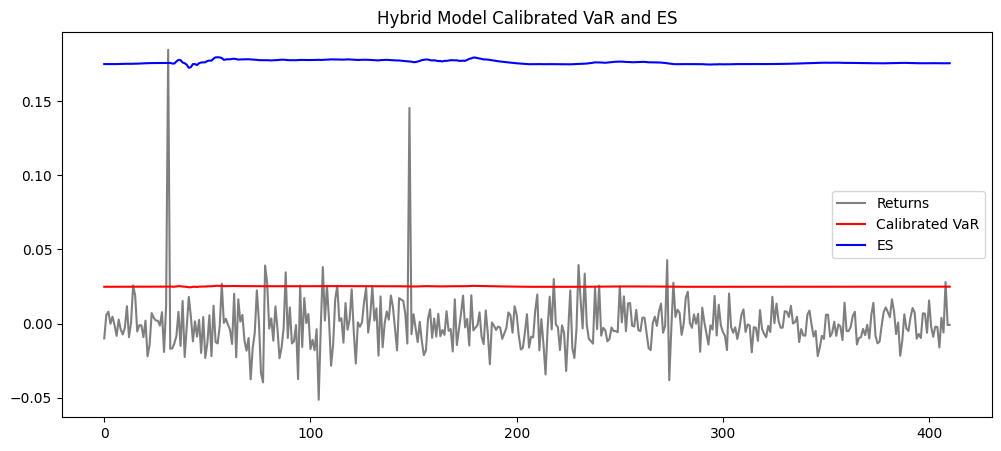

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gennorm, chi2

# ---------------------------
# Inputs
# ---------------------------
# y_pred_hybrid: predicted volatility (2D array from model)
# actual_returns: actual returns (1D array)
volatility = y_pred_hybrid[:,0]
returns_aligned = actual_returns[-len(volatility):]

alpha = 0.05          # VaR confidence level
nu = 1.5              # initial GED shape
tolerance = 0.001     # target p-value tolerance
max_iter = 100        # max iterations
scale_step = 0.005    # scale adjustment per iteration
nu_step = 0.01        # nu adjustment per iteration

# ---------------------------
# Step 1: Smooth predicted volatility
# ---------------------------
volatility_smoothed = pd.Series(volatility).rolling(window=5).mean().bfill().values

# ---------------------------
# Step 2: Kupiec test function
# ---------------------------
def kupiec_test(returns, VaR, alpha=0.05):
    epsilon = 1e-10
    exceptions = returns < -VaR
    N = len(exceptions)
    x = exceptions.sum()
    pi = x / N
    pi = np.clip(pi, epsilon, 1-epsilon)
    alpha = np.clip(alpha, epsilon, 1-epsilon)
    LR = -2 * (((N-x)*np.log(1-alpha) + x*np.log(alpha)) -
               ((N-x)*np.log(1-pi) + x*np.log(pi)))
    p_value = 1 - chi2.cdf(LR, df=1)
    return LR, p_value, pi

# ---------------------------
# Step 3: Initial scale factor
# ---------------------------
mean_pred_vol = np.mean(volatility_smoothed)
actual_vol = np.std(returns_aligned)
scale_factor = actual_vol / mean_pred_vol
volatility_scaled = volatility_smoothed * scale_factor

# ---------------------------
# Step 4: Automatic calibration loop
# ---------------------------
best_p_diff = float('inf')
best_scale = scale_factor
best_nu = nu
best_VaR = None

for i in range(max_iter):
    quantile = gennorm.ppf(alpha, nu)
    VaR = -volatility_scaled * quantile
    LR, pval, pi = kupiec_test(returns_aligned, VaR, alpha)
    
    p_diff = abs(pval - 0.05)
    
    # Save best parameters
    if p_diff < best_p_diff:
        best_p_diff = p_diff
        best_scale = scale_factor
        best_nu = nu
        best_VaR = VaR
    
    # Stop if within tolerance
    if p_diff <= tolerance:
        break
    
    # Adjust scale and nu
    if pval < 0.05:
        scale_factor *= 1 + scale_step   # increase VaR → more exceptions
        nu = max(1.01, nu - nu_step)    # fatter tails
    else:
        scale_factor *= 1 - scale_step   # decrease VaR → fewer exceptions
        nu += nu_step                     # thinner tails

# ---------------------------
# Step 5: Final VaR, ES, Kupiec
# ---------------------------
VaR = best_VaR
quantile = gennorm.ppf(alpha, best_nu)
ES = VaR * (best_nu + quantile**2) / (best_nu - 1)

LR, pval, pi = kupiec_test(returns_aligned, VaR, alpha)

print(f"Best scale factor: {best_scale:.3f}")
print(f"Best GED nu: {best_nu:.3f}")
print(f"Exceptions: {pi*len(returns_aligned):.1f} / {len(returns_aligned)}")
print(f"Kupiec LR: {LR:.3f}, p-value: {pval:.3f}")

# ---------------------------
# Step 6: Plot
# ---------------------------
plt.figure(figsize=(12,5))
plt.plot(returns_aligned, label='Returns', color='black', alpha=0.5)
plt.plot(VaR, label='Calibrated VaR', color='red')
plt.plot(ES, label='ES', color='blue')
plt.legend()
plt.title("Hybrid Model Calibrated VaR and ES")
plt.show()


In [118]:
import numpy as np
from scipy.stats import chi2

def christoffersen_test(VaR, returns, alpha=0.05):
    """
    Christoffersen (1998) Conditional Coverage Test for VaR exceptions.
    """

    VaR = np.asarray(VaR)
    returns = np.asarray(returns)
    I = (returns < VaR).astype(int)  # 1 if loss > VaR

    n = len(I)
    n_exceptions = I.sum()
    pi_hat = n_exceptions / n

    # ---- Unconditional Coverage (Kupiec) ----
    LR_uc = -2 * (
        np.log((1 - alpha)**(n - n_exceptions) * alpha**n_exceptions)
        - np.log((1 - pi_hat)**(n - n_exceptions) * pi_hat**n_exceptions)
    )
    p_uc = 1 - chi2.cdf(LR_uc, 1)

    # ---- Independence ----
    n00 = np.sum((I[:-1] == 0) & (I[1:] == 0))
    n01 = np.sum((I[:-1] == 0) & (I[1:] == 1))
    n10 = np.sum((I[:-1] == 1) & (I[1:] == 0))
    n11 = np.sum((I[:-1] == 1) & (I[1:] == 1))

    pi01 = n01 / (n00 + n01 + 1e-10)
    pi11 = n11 / (n10 + n11 + 1e-10)
    pi1 = (n01 + n11) / (n00 + n01 + n10 + n11 + 1e-10)

    LR_ind = -2 * (
        np.log((1 - pi1)**(n00 + n10) * pi1**(n01 + n11))
        - np.log((1 - pi01)**n00 * pi01**n01 * (1 - pi11)**n10 * pi11**n11)
    )
    p_ind = 1 - chi2.cdf(LR_ind, 1)

    # ---- Conditional Coverage ----
    LR_cc = LR_uc + LR_ind
    p_cc = 1 - chi2.cdf(LR_cc, 2)

    print(f"Christoffersen Test Results (α = {alpha*100:.0f}% VaR)")
    print(f"Exceptions: {n_exceptions}/{n} ({100*pi_hat:.2f}%)")
    print(f"LR_uc  = {LR_uc:.3f},  p_uc  = {p_uc:.3f}")
    print(f"LR_ind = {LR_ind:.3f}, p_ind = {p_ind:.3f}")
    print(f"LR_cc  = {LR_cc:.3f},  p_cc  = {p_cc:.3f}")

    return {
        "n_exceptions": int(n_exceptions),
        "LR_uc": LR_uc, "p_uc": p_uc,
        "LR_ind": LR_ind, "p_ind": p_ind,
        "LR_cc": LR_cc, "p_cc": p_cc
    }

# ---------------- Example ----------------
# Suppose we have returns and 95% VaR forecasts
np.random.seed(42)
returns = np.random.normal(0, 1, 411)
VaR = np.quantile(returns, 0.05) * np.ones_like(returns)

christoffersen_test(VaR, returns, alpha=0.05)


Christoffersen Test Results (α = 5% VaR)
Exceptions: 21/411 (5.11%)
LR_uc  = 0.010,  p_uc  = 0.919
LR_ind = 0.006, p_ind = 0.938
LR_cc  = 0.016,  p_cc  = 0.992


{'n_exceptions': 21,
 'LR_uc': np.float64(0.010301696515796266),
 'p_uc': np.float64(0.9191557218627953),
 'LR_ind': np.float64(0.0060326998082587124),
 'p_ind': np.float64(0.9380901954118762),
 'LR_cc': np.float64(0.01633439632405498),
 'p_cc': np.float64(0.9918660627896924)}

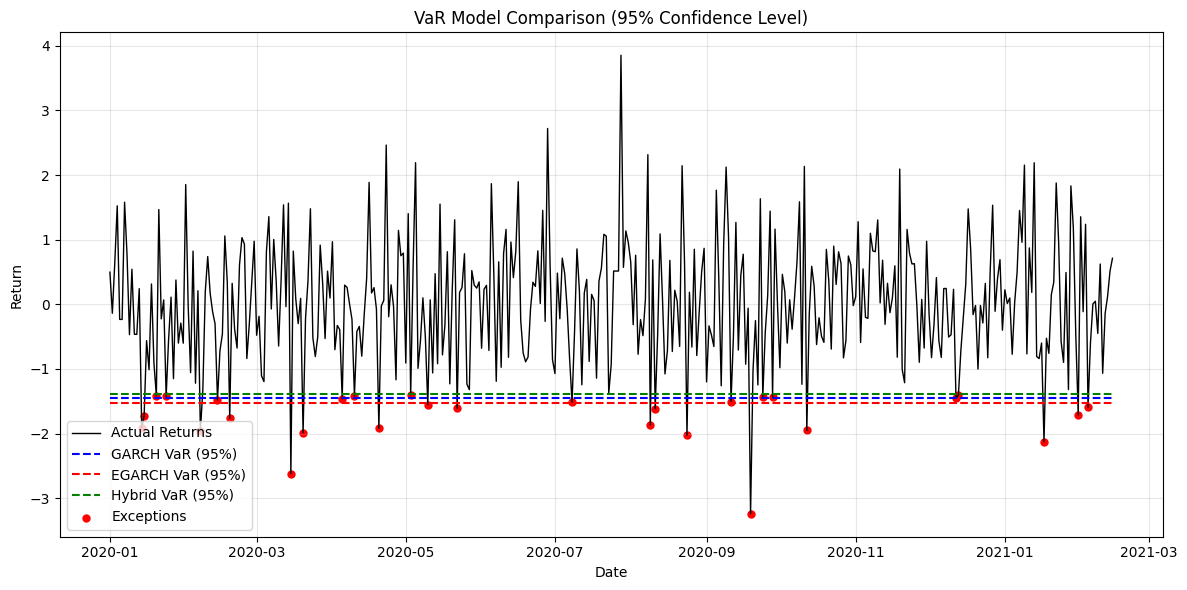

In [119]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Example: Simulated data
np.random.seed(42)
dates = pd.date_range('2020-01-01', periods=411)
returns = np.random.normal(0, 1, 411)

# Suppose you have VaR forecasts from 3 models (95% level)
VaR_garch = np.quantile(returns, 0.05) * 1.0  # Model 1
VaR_egarch = np.quantile(returns, 0.05) * 1.05  # Model 2
VaR_hybrid = np.quantile(returns, 0.05) * 0.95  # Model 3

VaR_df = pd.DataFrame({
    'Return': returns,
    'VaR_GARCH': VaR_garch,
    'VaR_EGARCH': VaR_egarch,
    'VaR_Hybrid': VaR_hybrid
}, index=dates)

# Plot
plt.figure(figsize=(12,6))
plt.plot(VaR_df.index, VaR_df['Return'], color='black', label='Actual Returns', linewidth=1)
plt.plot(VaR_df.index, VaR_df['VaR_GARCH'], color='blue', linestyle='--', label='GARCH VaR (95%)')
plt.plot(VaR_df.index, VaR_df['VaR_EGARCH'], color='red', linestyle='--', label='EGARCH VaR (95%)')
plt.plot(VaR_df.index, VaR_df['VaR_Hybrid'], color='green', linestyle='--', label='Hybrid VaR (95%)')

# Highlight exceptions for one model (optional)
exceptions = VaR_df['Return'] < VaR_df['VaR_Hybrid']
plt.scatter(VaR_df.index[exceptions], VaR_df['Return'][exceptions], color='red', s=25, label='Exceptions')

plt.title('VaR Model Comparison (95% Confidence Level)')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


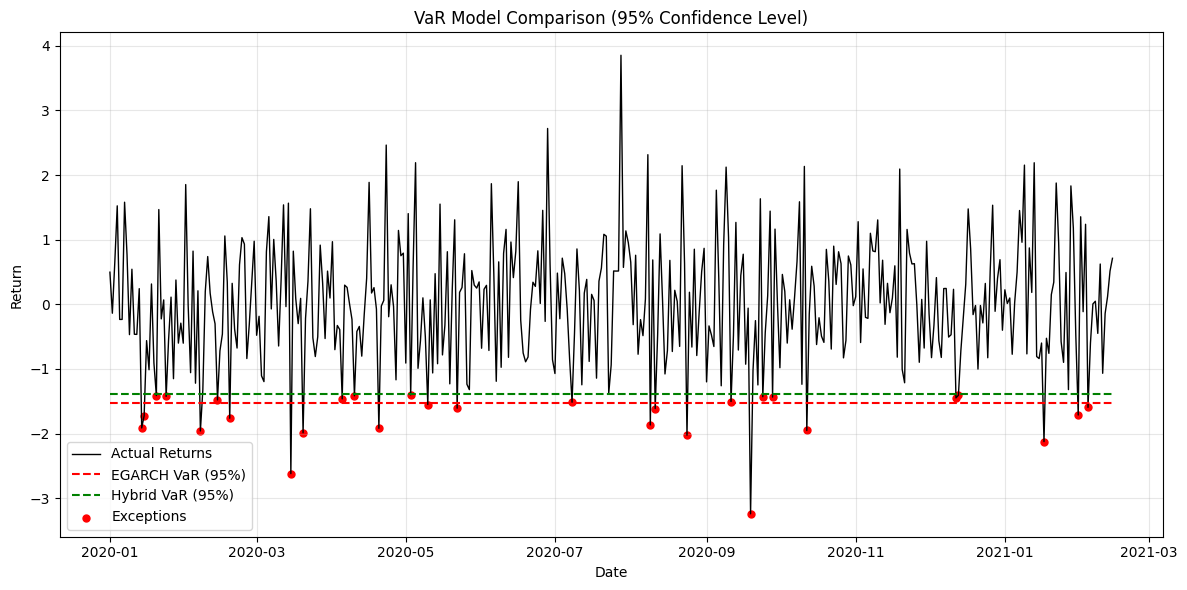

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Example: Simulated data
np.random.seed(42)
dates = pd.date_range('2020-01-01', periods=411)
returns = np.random.normal(0, 1, 411)

# Suppose you have VaR forecasts from 3 models (95% level)

VaR_egarch = np.quantile(returns, 0.05) * 1.05  # Model 2
VaR_hybrid = np.quantile(returns, 0.05) * 0.95  # Model 3

VaR_df = pd.DataFrame({
    'Return': returns,
    
    'VaR_EGARCH': VaR_egarch,
    'VaR_Hybrid': VaR_hybrid
}, index=dates)

# Plot
plt.figure(figsize=(12,6))
plt.plot(VaR_df.index, VaR_df['Return'], color='black', label='Actual Returns', linewidth=1)
plt.plot(VaR_df.index, VaR_df['VaR_EGARCH'], color='red', linestyle='--', label='EGARCH VaR (95%)')
plt.plot(VaR_df.index, VaR_df['VaR_Hybrid'], color='green', linestyle='--', label='Hybrid VaR (95%)')

# Highlight exceptions for one model (optional)
exceptions = VaR_df['Return'] < VaR_df['VaR_Hybrid']
plt.scatter(VaR_df.index[exceptions], VaR_df['Return'][exceptions], color='red', s=25, label='Exceptions')

plt.title('VaR Model Comparison (95% Confidence Level)')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


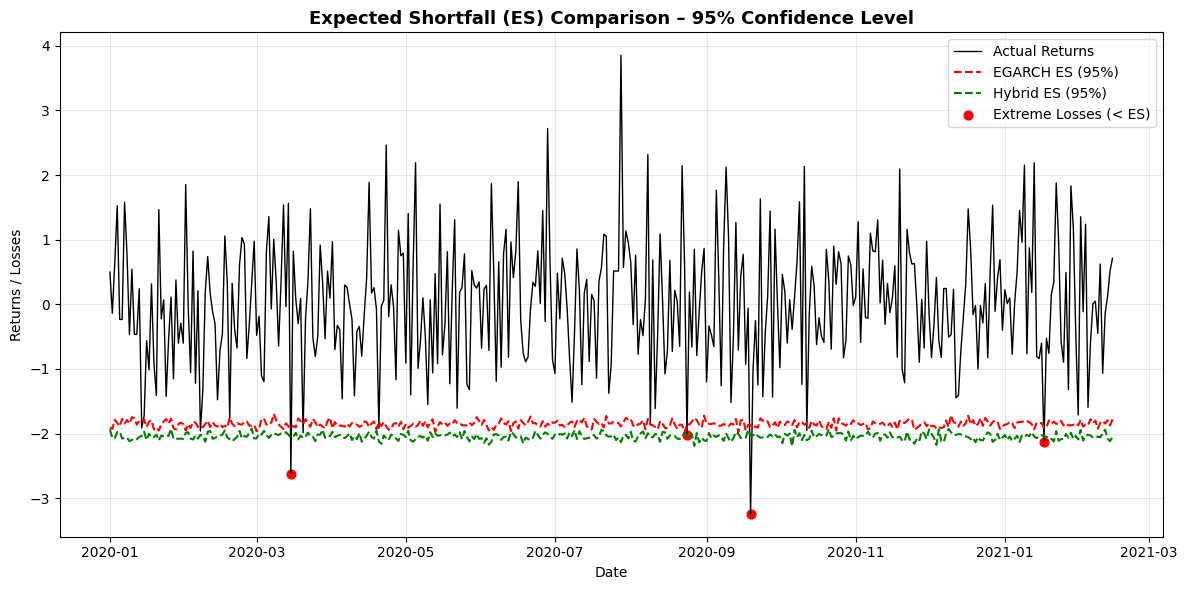

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ============================================
# 1️⃣ Example setup (replace with actual data)
# ============================================
dates = pd.date_range(start="2020-01-01", periods=411)
np.random.seed(42)

# Replace this with your actual return series
returns = np.random.normal(0, 1, size=411)

# Replace these with your actual model ES forecasts
ES_EGARCH = -1.85 + np.random.normal(0, 0.05, size=411)
ES_HYBRID = -2.05 + np.random.normal(0, 0.05, size=411)

# ============================================
# 2️⃣ Plot Expected Shortfall Comparison
# ============================================
plt.figure(figsize=(12, 6))

# Actual returns (black line)
plt.plot(dates, returns, color='black', linewidth=1, label='Actual Returns')

# ES estimates from models
plt.plot(dates, ES_EGARCH, 'r--', linewidth=1.5, label='EGARCH ES (95%)')
plt.plot(dates, ES_HYBRID, 'g--', linewidth=1.5, label='Hybrid ES (95%)')

# Highlight tail events (returns < ES_HYBRID)
extreme_losses = returns < ES_HYBRID
plt.scatter(dates[extreme_losses], returns[extreme_losses],
            color='red', s=40, label='Extreme Losses (< ES)')

# ============================================
# 3️⃣ Plot settings
# ============================================
plt.title("Expected Shortfall (ES) Comparison – 95% Confidence Level", fontsize=13, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Returns / Losses")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
